# STA for Hatano-Nelson Model — Truncated Krylov AGP

Hamiltonian:
$$
H(t) = \sum_{n=1}^{N-1}\left[\frac{J}{2}e^{ah(t)}c_n^\dagger c_{n+1}
        +\frac{J}{2}e^{-ah(t)}c_{n+1}^\dagger c_n
        + U\,c_n^\dagger c_n c_{n+1}^\dagger c_{n+1}\right]
$$

Compared to `STA_Hatano_Nelson_Arnoldi.ipynb` this notebook:
- Replaces the full exact AGP (expensive) with a **truncated Krylov AGP** via `KrylovKit_AGP_finite`
- Scales to larger system size **N = 8** (Hilbert-space dim = C(8,4) = 70)
- Sweeps several Krylov truncation depths `target_dim` to show convergence

In [19]:
using LinearAlgebra, SparseArrays, Plots, LaTeXStrings, Base.Threads, ProgressMeter

include("Hatano_Nelson.jl")
using .Hatano_Nelson

include("KrylovKitAGP.jl")
using .KrylovKitAGP

# Full Evolution with CD

In [11]:
# ── Thread / BLAS setup ───────────────────────────────────────────────────────
# BLAS spawns its own threads; inside @threads that creates oversubscription.
# Pin BLAS to 1 thread and let Julia's @threads own the cores.
BLAS.set_num_threads(1)
println("Julia threads: ", Threads.nthreads())   # launch with JULIA_NUM_THREADS=auto

# ── Parameters ────────────────────────────────────────────────────────────────
const N       = 8
const J, U, a, h0 = 1.0, 1.0, 1.0, 0.1
const M_STEPS = 150
const K_DIM   = 80
const τ_list  = collect(1:1:50)

# ── Precompute step Hamiltonians (τ-independent) ──────────────────────────────
# At Trotter step j: h = h0*(j-1)/M  →  independent of τ.
# Calling build_H_and_dHdt at τ_ref=1 gives dH_sp = h0 * ∂H/∂h ≡ dH_scaled.
# The actual derivative at real τ is:  dH/dt = dH_scaled / τ.
println("Precomputing $(M_STEPS+1) Hamiltonians (once, reused for all τ) …")
const H_steps         = Vector{Matrix{ComplexF64}}(undef, M_STEPS + 1)
const dH_scaled_steps = Vector{Matrix{ComplexF64}}(undef, M_STEPS + 1)
for j in 1:(M_STEPS + 1)
    s = (j - 1) / M_STEPS           # normalised time s = t/τ ∈ [0, 1]
    H_sp, dH_sp = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, 1.0, s)
    H_steps[j]         = Matrix(H_sp)
    dH_scaled_steps[j] = Matrix(dH_sp)   # = τ * (dH/dt);  divide by τ at runtime
end
println("Done.")

# ── Initial state ─────────────────────────────────────────────────────────────
diag0    = eigen(H_steps[1])
gs_idx   = argmin(real.(diag0.values))
ψ0       = normalize(diag0.vectors[:, gs_idx])
E_ground = diag0.values[gs_idx]
println("Ground-state energy E₀ = ", round(E_ground, digits=6))

# ── Bare ramp ─────────────────────────────────────────────────────────────────
function ramp_bare(τ; M=M_STEPS)
    dt = τ / M
    ψt = copy(ψ0)
    for j in 1:M
        ψt = exp(-im * H_steps[j] * dt) * ψt
        ψt ./= norm(ψt)
    end
    E = dot(ψt, H_steps[M + 1] * ψt)
    return real(E) - real(E_ground), imag(E) - imag(E_ground)
end

# ── CD ramp ───────────────────────────────────────────────────────────────────
function ramp_cd(τ; M=M_STEPS, kd=K_DIM)
    dt = τ / M
    ψt = copy(ψ0)
    for j in 1:M
        H_m  = H_steps[j]
        dH_m = dH_scaled_steps[j] / τ     # recover dH/dt for this τ
        A_cd = KrylovKitAGP.KrylovKit_AGP_finite(H_m, dH_m, kd)
        ψt   = exp(-im * (H_m + A_cd) * dt) * ψt
        ψt ./= norm(ψt)
    end
    E = dot(ψt, H_steps[M + 1] * ψt)
    return real(E) - real(E_ground), imag(E) - imag(E_ground)
end

# ── Sweeps (parallelised over τ) ──────────────────────────────────────────────
E_real_bare = zeros(length(τ_list));  E_imag_bare = zeros(length(τ_list))
E_real_cd   = zeros(length(τ_list));  E_imag_cd   = zeros(length(τ_list))

println("Bare ramp …")
@threads for i in eachindex(τ_list)
    E_real_bare[i], E_imag_bare[i] = ramp_bare(τ_list[i])
end

println("CD ramp (K = $K_DIM) …")
@threads for i in eachindex(τ_list)
    E_real_cd[i], E_imag_cd[i] = ramp_cd(τ_list[i])
end

Julia threads: 10
Precomputing 151 Hamiltonians (once, reused for all τ) …
Done.
Ground-state energy E₀ = -1.736322
Bare ramp …
CD ramp (K = 80) …


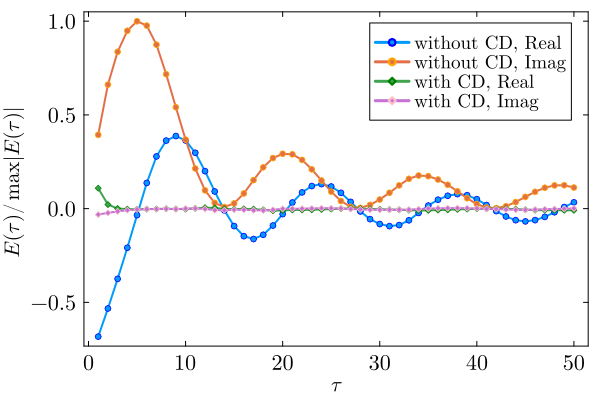

In [18]:
# ── Plot ──────────────────────────────────────────────────────────────────────
max_Eτ = maximum(abs.(E_real_bare .+ im .* E_imag_bare))

p = plot(titlefontsize=18, guidefontsize=16, tickfontsize=14,
         legendfontsize=12, labelfontsize=14, frame=:box,
         grid=false, fontfamily="Computer Modern")

plot!(τ_list, E_real_bare ./ max_Eτ,
      marker=:o,       markersize=3, markerstrokecolor=:blue,   label="without CD, Real", lw = 2)
plot!(τ_list, E_imag_bare ./ max_Eτ,
      marker=:o,       markersize=3, markerstrokecolor=:orange, label="without CD, Imag", lw = 2)
plot!(τ_list, E_real_cd ./ max_Eτ,
      marker=:diamond, markersize=3, markerstrokecolor=:green,  label="with CD, Real", lw = 2)
plot!(τ_list, E_imag_cd ./ max_Eτ,
      marker=:diamond, markersize=3, markerstrokecolor=:pink,   label="with CD, Imag", lw = 2)

plot!(xlabel=L"$\tau$", ylabel=L"$E(\tau)/\max|E(\tau)|$", legend=:topright)

#savefig(p, "Excess_energy.pdf")